In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
def I_T(I_0, mu, t):
    return np.exp(-mu * t) * I_0

def taylor_I_T(I_0, mu, t):
    '''Third order TE'''
    return I_0 * (1 - mu * t + (mu * t)^2 / 2 - (mu * t)^3 /6)

In [4]:
muE = pd.read_csv('ref_Ni_K_XAFS.csv', sep=',', usecols=['energy', 'IT_cps_ave', 'I0_cps_ave'])
muE.head()

,energy,IT_cps_ave,I0_cps_ave
0,8208.0,144074.666584,195549.934306
1,8210.5,143755.579750,194935.183326
2,8213.0,142060.603724,193117.326379
3,8215.5,144227.089134,195520.484793
4,8218.0,144260.903057,195915.643960


In [10]:
def taylor_homo(mu_t):
    return 1 - mu_t + (mu_t)**2 / 2 - (mu_t)**3 / 6

def taylor_frac(mu_t, x : float):
    return 1 - mu_t + (mu_t)**2 / (2 * x) - (mu_t)**3 / (6 * x**2) 

<function matplotlib.pyplot.show(close=None, block=None)>

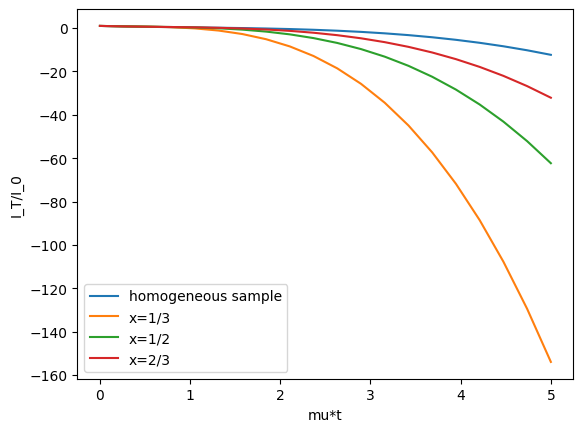

In [11]:
mu_t = np.linspace(0, 5, 20)
plt.plot(mu_t, taylor_homo(mu_t), label='homogeneous sample')
plt.plot(mu_t, taylor_frac(mu_t, 1/3), label='x=1/3')
plt.plot(mu_t, taylor_frac(mu_t, 0.5), label='x=1/2')
plt.plot(mu_t, taylor_frac(mu_t, 2/3), label='x=2/3')
plt.xlabel('mu*t')
plt.ylabel('I_T/I_0')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

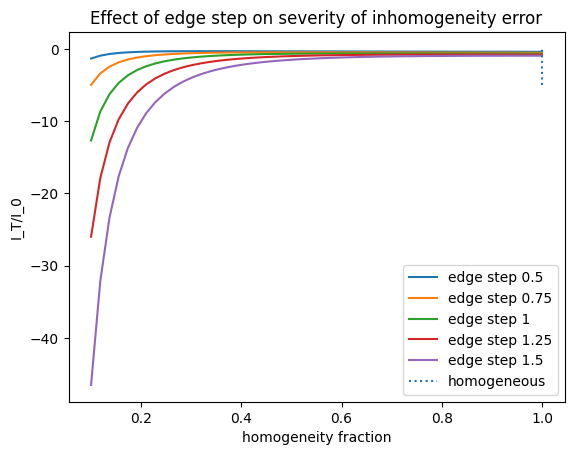

In [20]:
x = np.linspace(0.1, 1, 50)
plt.plot(x, taylor_frac(0.5, x) - taylor_frac(0, x), label='edge step 0.5')
plt.plot(x, taylor_frac(0.75, x) - taylor_frac(0, x), label='edge step 0.75')
plt.plot(x, taylor_frac(1, x) - taylor_frac(0, x), label='edge step 1')
plt.plot(x, taylor_frac(1.25, x) - taylor_frac(0, x), label='edge step 1.25')
plt.plot(x, taylor_frac(1.5, x) - taylor_frac(0, x), label='edge step 1.5')
plt.vlines(1, -5, 0, linestyles='dotted', label='homogeneous')
plt.title('Effect of edge step on severity of inhomogeneity error')
plt.xlabel('homogeneity fraction')
plt.ylabel('I_T/I_0')
plt.legend()
plt.show

In [9]:
print(mu_t)

[0.         0.26315789 0.52631579 0.78947368 1.05263158 1.31578947
 1.57894737 1.84210526 2.10526316 2.36842105 2.63157895 2.89473684
 3.15789474 3.42105263 3.68421053 3.94736842 4.21052632 4.47368421
 4.73684211 5.        ]
